In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer, make_column_transformer
from sklearn.dummy import DummyRegressor
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    GridSearchCV,
    cross_val_score,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder

C:\Users\User\AppData\Local\Temp\ipykernel_22032\1252535573.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
os.chdir("/Users/User/desktop/JLW/ML Insurance Project")
print(os.getcwd())

C:\Users\User\desktop\JLW\ML Insurance Project


In [3]:
insuranceraw_df = pd.read_csv("data/insurance_claims.csv")
insuranceraw_df.shape

(1000, 40)

We can see we have 1000 observations with 40 features.

In [4]:
insuranceraw_df

,months_as_customer,age,policy_number,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_zip,...,police_report_available,total_claim_amount,injury_claim,property_claim,vehicle_claim,auto_make,auto_model,auto_year,fraud_reported,_c39
0,328,48,521585,2014-10-17,OH,250/500,1000,1406.91,0,466132,...,YES,71610,6510,13020,52080,Saab,92x,2004,Y,NaN
1,228,42,342868,2006-06-27,IN,250/500,2000,1197.22,5000000,468176,...,?,5070,780,780,3510,Mercedes,E400,2007,Y,NaN
2,134,29,687698,2000-09-06,OH,100/300,2000,1413.14,5000000,430632,...,NO,34650,7700,3850,23100,Dodge,RAM,2007,N,NaN
3,256,41,227811,1990-05-25,IL,250/500,2000,1415.74,6000000,608117,...,NO,63400,6340,6340,50720,Chevrolet,Tahoe,2014,Y,NaN
4,228,44,367455,2014-06-06,IL,500/1000,1000,1583.91,6000000,610706,...,NO,6500,1300,650,4550,Accura,RSX,2009,N,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,941851,1991-07-16,OH,500/1000,1000,1310.80,0,431289,...,?,87200,17440,8720,61040,Honda,Accord,2006,N,NaN
996,285,41,186934,2014-01-05,IL,100/300,1000,1436.79,0,608177,...,?,108480,18080,18080,72320,Volkswagen,Passat,2015,N,NaN
997,130,34,918516,2003-02-17,OH,250/500,500,1383.49,3000000,442797,...,YES,67500,7500,7500,52500,Suburu,Impreza,1996,N,NaN
998,458,62,533940,2011-11-18,IL,500/1000,2000,1356.92,5000000,441714,...,YES,46980,5220,5220,36540,Audi,A5,1998,N,NaN


Remove unecessary features to simplify model

In [5]:
drop_features = ['policy_number', 'insured_hobbies', 'capital-gains' , 
                 'capital-loss', 'authorities_contacted', 'insured_zip', 
                 'incident_city', 'incident_location', 'police_report_available', 
                 'injury_claim', 'property_claim', 'vehicle_claim', '_c39', 
                 'property_damage'
                ]
insurance_df = insuranceraw_df.drop(columns= drop_features)

In [6]:
insurance_df

,months_as_customer,age,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,...,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,auto_make,auto_model,auto_year,fraud_reported
0,328,48,2014-10-17,OH,250/500,1000,1406.91,0,MALE,MD,...,SC,5,1,1,2,71610,Saab,92x,2004,Y
1,228,42,2006-06-27,IN,250/500,2000,1197.22,5000000,MALE,MD,...,VA,8,1,0,0,5070,Mercedes,E400,2007,Y
2,134,29,2000-09-06,OH,100/300,2000,1413.14,5000000,FEMALE,PhD,...,NY,7,3,2,3,34650,Dodge,RAM,2007,N
3,256,41,1990-05-25,IL,250/500,2000,1415.74,6000000,FEMALE,PhD,...,OH,5,1,1,2,63400,Chevrolet,Tahoe,2014,Y
4,228,44,2014-06-06,IL,500/1000,1000,1583.91,6000000,MALE,Associate,...,NY,20,1,0,1,6500,Accura,RSX,2009,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,3,38,1991-07-16,OH,500/1000,1000,1310.80,0,FEMALE,Masters,...,NC,20,1,0,1,87200,Honda,Accord,2006,N
996,285,41,2014-01-05,IL,100/300,1000,1436.79,0,FEMALE,PhD,...,SC,23,1,2,3,108480,Volkswagen,Passat,2015,N
997,130,34,2003-02-17,OH,250/500,500,1383.49,3000000,FEMALE,Masters,...,NC,4,3,2,3,67500,Suburu,Impreza,1996,N
998,458,62,2011-11-18,IL,500/1000,2000,1356.92,5000000,MALE,Associate,...,NY,2,1,0,1,46980,Audi,A5,1998,N


We can view column types to help organize which feature should be categorized as what type.

In [7]:
insurance_df.describe(include='all')

,months_as_customer,age,policy_bind_date,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,...,incident_state,incident_hour_of_the_day,number_of_vehicles_involved,bodily_injuries,witnesses,total_claim_amount,auto_make,auto_model,auto_year,fraud_reported
count,1000.000000,1000.000000,1000,1000,1000,1000.000000,1000.000000,1.000000e+03,1000,1000,...,1000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000,1000,1000,1000.000000,1000
unique,NaN,NaN,951,3,3,NaN,NaN,NaN,2,7,...,7,NaN,NaN,NaN,NaN,NaN,14,39,NaN,2
top,NaN,NaN,2006-01-01,OH,250/500,NaN,NaN,NaN,FEMALE,JD,...,NY,NaN,NaN,NaN,NaN,NaN,Saab,RAM,NaN,N
freq,NaN,NaN,3,352,351,NaN,NaN,NaN,537,161,...,262,NaN,NaN,NaN,NaN,NaN,80,43,NaN,753
mean,203.954000,38.948000,NaN,NaN,NaN,1136.000000,1256.406150,1.101000e+06,NaN,NaN,...,NaN,11.644000,1.83900,0.992000,1.487000,52761.94000,NaN,NaN,2005.103000,NaN
std,115.113174,9.140287,NaN,NaN,NaN,611.864673,244.167395,2.297407e+06,NaN,NaN,...,NaN,6.951373,1.01888,0.820127,1.111335,26401.53319,NaN,NaN,6.015861,NaN
min,0.000000,19.000000,NaN,NaN,NaN,500.000000,433.330000,-1.000000e+06,NaN,NaN,...,NaN,0.000000,1.00000,0.000000,0.000000,100.00000,NaN,NaN,1995.000000,NaN
25%,115.750000,32.000000,NaN,NaN,NaN,500.000000,1089.607500,0.000000e+00,NaN,NaN,...,NaN,6.000000,1.00000,0.000000,1.000000,41812.50000,NaN,NaN,2000.000000,NaN
50%,199.500000,38.000000,NaN,NaN,NaN,1000.000000,1257.200000,0.000000e+00,NaN,NaN,...,NaN,12.000000,1.00000,1.000000,1.000000,58055.00000,NaN,NaN,2005.000000,NaN
75%,276.250000,44.000000,NaN,NaN,NaN,2000.000000,1415.695000,0.000000e+00,NaN,NaN,...,NaN,17.000000,3.00000,2.000000,2.000000,70592.50000,NaN,NaN,2010.000000,NaN


In [8]:
insurance_df["policy_bind_date"] = pd.to_datetime(insurance_df["policy_bind_date"], errors="coerce")
insurance_df["policy_bind_year"] = insurance_df["policy_bind_date"].dt.year

insurance_df = insurance_df.drop(columns= 'policy_bind_date') 

We will turn the bind date, into a bind year column for generalization and a more comprehendable feature. 

In [9]:
train_df, test_df = train_test_split(insurance_df.replace("?", np.nan), test_size = 0.3, random_state = 123)

Split up our data into training and testing sets to check performance of our model at the end.

In [10]:
X_train = train_df.drop(columns=['total_claim_amount'])
y_train = train_df['total_claim_amount']
X_test = test_df.drop(columns=['total_claim_amount'])
y_test = test_df['total_claim_amount']

Create separate dataframes with the feature we aim to predict

In [11]:
insurance_df.columns

Index(['months_as_customer', 'age', 'policy_state', 'policy_csl',
       'policy_deductable', 'policy_annual_premium', 'umbrella_limit',
       'insured_sex', 'insured_education_level', 'insured_occupation',
       'insured_relationship', 'incident_date', 'incident_type',
       'collision_type', 'incident_severity', 'incident_state',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'total_claim_amount', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', 'policy_bind_year'],
      dtype='object')

In [12]:
drop_features

['policy_number',
 'insured_hobbies',
 'capital-gains',
 'capital-loss',
 'authorities_contacted',
 'insured_zip',
 'incident_city',
 'incident_location',
 'police_report_available',
 'injury_claim',
 'property_claim',
 'vehicle_claim',
 '_c39',
 'property_damage']

In [13]:
numeric_features = ['months_as_customer', 'age', 'policy_annual_premium', ]
categorical_features = ['policy_state', 'policy_csl', 'policy_deductable', 'umbrella_limit', 
                         'insured_occupation', 'insured_relationship', 'incident_type', 
                        'collision_type', 'incident_severity', 'incident_state', 'incident_hour_of_the_day', 
                        'number_of_vehicles_involved', 'bodily_injuries', 'witnesses', 
                        'auto_make', 'auto_model', 'auto_year', 'policy_bind_year'
                       ]
ordinal_features = ['insured_education_level']
education_levels = ['High School', 'College', 'Associate', 'MD', 'JD', 'Masters', 'PhD']

binary_features = ['insured_sex', 'fraud_reported']
#time_features = ['policy_bind_date']
# Try to turn this into a month/year thing rather than a specific date, or maybe even jsut year

Categorize our features into numeric, categorical, ordinal, and binary; we can then apply specific transformations on types of features.

In [14]:
numeric_transformer = StandardScaler()

binary_transformer = make_pipeline(OneHotEncoder(handle_unknown="ignore", drop="if_binary", dtype=int, sparse_output=False))

categorical_transformer = make_pipeline(OneHotEncoder(handle_unknown="ignore", sparse_output=False))

ordinal_transformer = make_pipeline(OrdinalEncoder(categories=[education_levels], dtype=int))

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_features),
    ('bin', binary_transformer, binary_features),
    ('cat', categorical_transformer, categorical_features),
    ('ord', ordinal_transformer, ordinal_features),
])

We will apply standard scaling to numeric features: setting the mean to 0 and sd to 1. We will apply one hot encoding to our binary and categorical features creating a new column for each unique category. We will then apply ordinal encoding on our education levels to give more weight to higher levels of education.

Scaling allows certain models to be more effective, and one hot encoding turns our categorical values into numbers so a model can take it in.

In [15]:
results_dict = {}

In [16]:
def mean_std_cross_val_scores(model, X_train, y_train, **kwargs):
    """
    Returns mean and std of cross validation

    Parameters
    ----------
    model :
        scikit-learn model
    X_train : numpy array or pandas DataFrame
        X in the training data
    y_train :
        y in the training data

    Returns
    ----------
        pandas Series with mean scores from cross_validation
    """

    scores = cross_validate(model, X_train, y_train, **kwargs)

    mean_scores = pd.DataFrame(scores).mean()
    std_scores = pd.DataFrame(scores).std()
    out_col = []

    for i in range(len(mean_scores)):
        out_col.append((f"%0.3f (+/- %0.3f)" % (mean_scores.iloc[i], std_scores.iloc[i])))

    return pd.Series(data=out_col, index=mean_scores.index)

A function adapted from my CPSC machine learning course. Takes in a model, the dataframe with our predicting features, and the dataframe containing the feature we want to predict. It runs cross validation with our data set to get a train score then runs the model one last time with the second dataframe. It also returns the time it took to fit and score the model.

In [17]:
dummy = DummyRegressor(strategy='mean')
pipe = make_pipeline(preprocessor, dummy)
results_dict["dummy"] = mean_std_cross_val_scores(
    pipe, X_train, y_train, cv=5, return_train_score=True
)

results_df = pd.DataFrame(results_dict).T
results_df

,fit_time,score_time,test_score,train_score
dummy,0.021 (+/- 0.005),0.010 (+/- 0.001),-0.014 (+/- 0.021),0.000 (+/- 0.000)


Creating a dummy model first to have a baseline, we are using the strategy mean which predicts the mean of the feature we want to predict no matter what. This has scored poorly which we expect.

In [18]:
lr = LinearRegression()

pipelr = make_pipeline(preprocessor, lr)

results_dict["Linear regression"] = mean_std_cross_val_scores(
    pipelr, X_train, y_train, cv=5, return_train_score=True
)

results_df = pd.DataFrame(results_dict).T
results_df

,fit_time,score_time,test_score,train_score
dummy,0.021 (+/- 0.005),0.010 (+/- 0.001),-0.014 (+/- 0.021),0.000 (+/- 0.000)
Linear regression,0.070 (+/- 0.013),0.011 (+/- 0.001),-4999439420375244800.000 (+/- 1117908639335119...,0.782 (+/- 0.007)


Linear regression performed very well on the training set, but horribly on the test set. This is a sign of overfitting.

In [19]:
rf = RandomForestRegressor(random_state = 123)

piperf = make_pipeline(preprocessor, rf)

results_dict["Random Forest"] = mean_std_cross_val_scores(
    piperf, X_train, y_train, cv=5, return_train_score=True
)

results_df = pd.DataFrame(results_dict).T
results_df


,fit_time,score_time,test_score,train_score
dummy,0.021 (+/- 0.005),0.010 (+/- 0.001),-0.014 (+/- 0.021),0.000 (+/- 0.000)
Linear regression,0.070 (+/- 0.013),0.011 (+/- 0.001),-4999439420375244800.000 (+/- 1117908639335119...,0.782 (+/- 0.007)
Random Forest,1.230 (+/- 0.014),0.017 (+/- 0.002),0.674 (+/- 0.017),0.955 (+/- 0.001)


Here our random forest model is performing quite well, we can see a very high train score which is expected as our random forest goes until every difference is accounted for. That being said we also see a good test score, random forest is an ensemble model which tend to perform well.

In [21]:
piperf.fit(X_train, y_train);

ohe_feature_names = (
    piperf.named_steps["columntransformer"]
    .named_transformers_["cat"]
    .named_steps["onehotencoder"]
    .get_feature_names_out(categorical_features)
    .tolist()
)

feature_names = (
    numeric_features + ordinal_features + binary_features +  ohe_feature_names
)

len(feature_names)

200

We will now run a feature importance to determine which features are providing the most useful information in predictions. 
We need all the column names, which means we will need to do some extra work to extract the column names from our one hot encoding.

In [22]:
data = {
    "Importance": piperf.named_steps["randomforestregressor"].feature_importances_,
}


In [23]:
rf_imp_df = pd.DataFrame(
    data=data,
    index=feature_names,
).sort_values(by="Importance", ascending=False)

In [24]:
rf_imp_df[:10]

,Importance
collision_type_Side Collision,0.693517
policy_annual_premium,0.031671
months_as_customer,0.020644
age,0.017058
policy_bind_year_2015,0.007817
bodily_injuries_1,0.004047
policy_bind_year_1996,0.003848
insured_relationship_husband,0.003754
policy_bind_year_2006,0.003214
incident_hour_of_the_day_14,0.003056


Here we can see that Side Collisions have the highest correlation to our claim amount. Followed by poly annual premiums, then months as customer, and so on. That being said, the margin for the Side Collision feature is quite large and almost makes everything else obsolete. These importances will sum to 1, so we can say that it attributes to 69.35% of our prediciton.

In [25]:
np.sum(piperf.named_steps["randomforestregressor"].feature_importances_)

1.0

In [26]:
insurance_df.columns

Index(['months_as_customer', 'age', 'policy_state', 'policy_csl',
       'policy_deductable', 'policy_annual_premium', 'umbrella_limit',
       'insured_sex', 'insured_education_level', 'insured_occupation',
       'insured_relationship', 'incident_date', 'incident_type',
       'collision_type', 'incident_severity', 'incident_state',
       'incident_hour_of_the_day', 'number_of_vehicles_involved',
       'bodily_injuries', 'witnesses', 'total_claim_amount', 'auto_make',
       'auto_model', 'auto_year', 'fraud_reported', 'policy_bind_year'],
      dtype='object')

In [27]:
train_df["incident_date"] = pd.to_datetime(train_df["incident_date"], errors="coerce")
train_df["incident_month"] = train_df["incident_date"].dt.month
test_df["incident_date"] = pd.to_datetime(test_df["incident_date"], errors="coerce")
test_df["incident_month"] = test_df["incident_date"].dt.month

drop_features_before = [ 'incident_date', 'incident_type', 'collision_type', 
                        'incident_severity','incident_state', 'incident_hour_of_the_day',
                        'number_of_vehicles_involved', 'bodily_injuries', 'witnesses',
                        'fraud_reported'
                ]



Now, after running our model with all predictors, we will now remove all the features that we would NOT have before the indident. 
We are converting incident date, to incident month for a more generalized predictor. Unfortunately, for this data set all the observations are in the first three months so we wont have information from all 12 months.



In [28]:
X_train_before = train_df.drop(columns = drop_features_before)
X_test_before = test_df.drop(columns = drop_features_before)

X_train_before.describe(include='all')

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_relationship,total_claim_amount,auto_make,auto_model,auto_year,policy_bind_year,incident_month
count,700.000000,700.000000,700,700,700.000000,700.000000,7.000000e+02,700,700,700,700,700.000000,700,700,700.000000,700.000000,700.000000
unique,NaN,NaN,3,3,NaN,NaN,NaN,2,7,14,6,NaN,14,39,NaN,NaN,NaN
top,NaN,NaN,OH,100/300,NaN,NaN,NaN,FEMALE,JD,machine-op-inspct,not-in-family,NaN,Dodge,RAM,NaN,NaN,NaN
freq,NaN,NaN,242,251,NaN,NaN,NaN,380,109,68,130,NaN,60,34,NaN,NaN,NaN
mean,207.061429,39.108571,NaN,NaN,1128.571429,1250.361429,1.030000e+06,NaN,NaN,NaN,NaN,52737.128571,NaN,NaN,2005.225714,2001.485714,1.500000
std,113.921103,9.123830,NaN,NaN,608.039335,240.843826,2.232665e+06,NaN,NaN,NaN,NaN,26442.266825,NaN,NaN,6.045410,7.326911,0.522731
min,0.000000,20.000000,NaN,NaN,500.000000,433.330000,-1.000000e+06,NaN,NaN,NaN,NaN,100.000000,NaN,NaN,1995.000000,1990.000000,1.000000
25%,120.000000,32.000000,NaN,NaN,500.000000,1087.807500,0.000000e+00,NaN,NaN,NaN,NaN,41697.500000,NaN,NaN,2000.000000,1995.000000,1.000000
50%,208.500000,39.000000,NaN,NaN,1000.000000,1252.600000,0.000000e+00,NaN,NaN,NaN,NaN,58065.000000,NaN,NaN,2005.000000,2002.000000,1.000000
75%,280.250000,45.000000,NaN,NaN,2000.000000,1407.522500,0.000000e+00,NaN,NaN,NaN,NaN,70530.000000,NaN,NaN,2010.000000,2008.000000,2.000000


Readjust our train and test sets to exclude our new features.

In [29]:
numeric_features2 = ['months_as_customer', 'age', 'policy_annual_premium', ]
categorical_features2 = ['policy_state', 'policy_csl', 'policy_deductable', 'umbrella_limit', 
                         'insured_occupation', 'insured_relationship',  
                        'auto_make', 'auto_model', 'auto_year', "incident_month", 'policy_bind_year'
                       ]
ordinal_features2 = ['insured_education_level']
education_levels = ['High School', 'College', 'Associate', 'MD', 'JD', 'Masters', 'PhD']

binary_features2 = ['insured_sex']

Create a second set of preprocessors and pipelines for our new set of features. A very similar process with only changes to what we include.

In [30]:
preprocessor2 = ColumnTransformer([
    ('num', numeric_transformer, numeric_features2),
    ('bin', binary_transformer, binary_features2),
    ('cat', categorical_transformer, categorical_features2),
    ('ord', ordinal_transformer, ordinal_features2),
])

In [31]:
results_dict2 = {}

In [32]:
lr2 = LinearRegression()

pipelr2 = make_pipeline(preprocessor2, lr2)

results_dict2["Linear regression 2"] = mean_std_cross_val_scores(
    pipelr2, X_train_before, y_train, cv=5, return_train_score=True
)

results_df = pd.DataFrame(results_dict2).T
results_df

,fit_time,score_time,test_score,train_score
Linear regression 2,0.048 (+/- 0.002),0.009 (+/- 0.001),-25535419076733558784.000 (+/- 570989328895211...,0.231 (+/- 0.021)


In [33]:
rf2 = RandomForestRegressor(random_state = 123)

piperf2 = make_pipeline(preprocessor2, rf2)

results_dict2["Random Forest 2"] = mean_std_cross_val_scores(
    piperf2, X_train_before, y_train, cv=5, return_train_score=True
)

results_df = pd.DataFrame(results_dict2).T
results_df

,fit_time,score_time,test_score,train_score
Linear regression 2,0.048 (+/- 0.002),0.009 (+/- 0.001),-25535419076733558784.000 (+/- 570989328895211...,0.231 (+/- 0.021)
Random Forest 2,1.033 (+/- 0.020),0.016 (+/- 0.001),-0.059 (+/- 0.051),0.852 (+/- 0.003)


After running our models, we can see the score went all the way down. This is a red flag that the features we were left with have little to no predictive powers on claim amount.

To try and work around this and test different models, we will adjust this into a clasification task rather than regression.

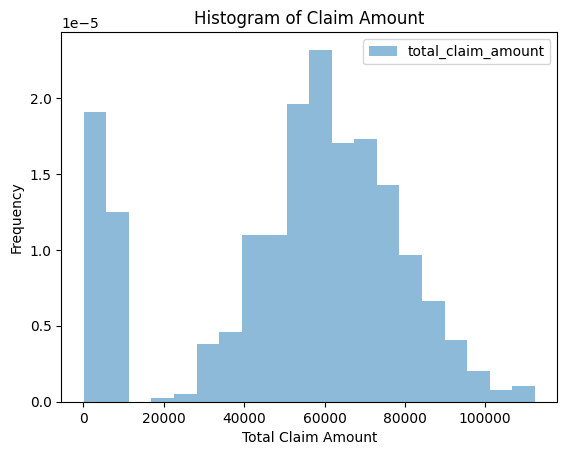

In [34]:
train_df["total_claim_amount"].plot.hist(bins=20, alpha=0.5, legend=True, density = True, title = "Histogram of Claim Amount");
plt.xlabel("Total Claim Amount");
plt.show();

First, we will visualize the distribution of our claim amounts to find out how many bins would be ideal and where we should ideally be splitting them.

In [35]:
def bucket(amount):
    if amount < 20000:
        return "low (0-10k)1"
    elif amount < 40000:
        return "low mid (10k-20k)2"
    elif amount < 60000:
        return "low mid (20k-30k)3"
    elif amount < 80000:
        return "low mid (20k-30k)4"
    elif amount < 100000:
        return "low mid (20k-30k)6"
    else:
        return "high (100k+)7"


train_df["claim_range"] = train_df["total_claim_amount"].apply(bucket)
test_df["claim_range"] = test_df["total_claim_amount"].apply(bucket)

train_df

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,...,bodily_injuries,witnesses,total_claim_amount,auto_make,auto_model,auto_year,fraud_reported,policy_bind_year,incident_month,claim_range
498,405,58,IL,250/500,500,1237.88,0,MALE,MD,exec-managerial,...,0,0,63580,Mercedes,ML350,1997,Y,2012,1,low mid (20k-30k)4
243,174,36,IL,100/300,2000,1278.75,0,FEMALE,College,tech-support,...,2,2,65400,Dodge,RAM,2012,N,2005,2,low mid (20k-30k)4
314,91,30,IL,250/500,2000,1316.63,8000000,FEMALE,Masters,machine-op-inspct,...,2,0,84500,BMW,X6,2009,N,2010,1,low mid (20k-30k)6
202,219,39,IN,250/500,2000,1281.07,7000000,FEMALE,High School,protective-serv,...,0,2,5920,Chevrolet,Malibu,2015,N,2007,1,low (0-10k)1
300,259,43,IL,100/300,500,947.75,0,FEMALE,Masters,farming-fishing,...,1,3,7680,Audi,A5,2008,N,2009,2,low (0-10k)1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
988,295,46,IN,100/300,500,1672.88,0,FEMALE,High School,armed-forces,...,1,1,60700,Honda,Civic,1997,N,1999,2,low mid (20k-30k)4
322,266,44,IL,250/500,500,1611.83,0,MALE,High School,handlers-cleaners,...,1,2,32800,BMW,3 Series,2012,N,1999,1,low mid (10k-20k)2
382,113,29,OH,250/500,2000,1091.73,0,MALE,PhD,exec-managerial,...,0,2,49950,Nissan,Ultima,2004,Y,2008,1,low mid (20k-30k)3
365,162,31,IN,100/300,1000,1050.24,0,FEMALE,Masters,adm-clerical,...,0,0,3600,BMW,X5,2013,Y,2006,2,low (0-10k)1


We have split it into bins separated by $20,000 dollar increments, and given them a tag/category that we will now try to predict similarly to how we tried to predict the numeric value.

As we now have a categorical variable, regressors such as linear regression will not work.
We will continue with logistic regression, and use random forest classification.

In [36]:
X_train_classification = train_df.drop(columns=["claim_range", "total_claim_amount"] + drop_features_before)
y_train_classification = train_df["claim_range"]
X_test_classification = test_df.drop(columns=["claim_range", "total_claim_amount"] + drop_features_before)
y_test_classification = test_df["claim_range"]

X_train_classification.describe(include='all')

,months_as_customer,age,policy_state,policy_csl,policy_deductable,policy_annual_premium,umbrella_limit,insured_sex,insured_education_level,insured_occupation,insured_relationship,auto_make,auto_model,auto_year,policy_bind_year,incident_month
count,700.000000,700.000000,700,700,700.000000,700.000000,7.000000e+02,700,700,700,700,700,700,700.000000,700.000000,700.000000
unique,NaN,NaN,3,3,NaN,NaN,NaN,2,7,14,6,14,39,NaN,NaN,NaN
top,NaN,NaN,OH,100/300,NaN,NaN,NaN,FEMALE,JD,machine-op-inspct,not-in-family,Dodge,RAM,NaN,NaN,NaN
freq,NaN,NaN,242,251,NaN,NaN,NaN,380,109,68,130,60,34,NaN,NaN,NaN
mean,207.061429,39.108571,NaN,NaN,1128.571429,1250.361429,1.030000e+06,NaN,NaN,NaN,NaN,NaN,NaN,2005.225714,2001.485714,1.500000
std,113.921103,9.123830,NaN,NaN,608.039335,240.843826,2.232665e+06,NaN,NaN,NaN,NaN,NaN,NaN,6.045410,7.326911,0.522731
min,0.000000,20.000000,NaN,NaN,500.000000,433.330000,-1.000000e+06,NaN,NaN,NaN,NaN,NaN,NaN,1995.000000,1990.000000,1.000000
25%,120.000000,32.000000,NaN,NaN,500.000000,1087.807500,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,2000.000000,1995.000000,1.000000
50%,208.500000,39.000000,NaN,NaN,1000.000000,1252.600000,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,2005.000000,2002.000000,1.000000
75%,280.250000,45.000000,NaN,NaN,2000.000000,1407.522500,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,2010.000000,2008.000000,2.000000


We can use the same features as before just adjusting our predictive category.

In [37]:
numeric_featuresC = ['months_as_customer', 'age', 'policy_annual_premium', ]
categorical_featuresC = ['policy_state', 'policy_csl', 'policy_deductable', 'umbrella_limit', 
                         'insured_occupation', 'insured_relationship',  
                        'auto_make', 'auto_model', 'auto_year', "incident_month", 'policy_bind_year'
                       ]
ordinal_featuresC = ['insured_education_level']
education_levels = ['High School', 'College', 'Associate', 'MD', 'JD', 'Masters', 'PhD']

binary_featuresC = ['insured_sex']

In [38]:
preprocessorC = ColumnTransformer([
    ('num', numeric_transformer, numeric_featuresC),
    ('bin', binary_transformer, binary_featuresC),
    ('cat', categorical_transformer, categorical_featuresC),
    ('ord', ordinal_transformer, ordinal_featuresC),
])

In [39]:
results_dict3 = {}

In [40]:
dummy = DummyClassifier(random_state = 123, strategy="most_frequent")

piped = make_pipeline(preprocessorC, dummy)

results_dict3["Dummy Classifier"] = mean_std_cross_val_scores(
    piped, X_train_classification, y_train_classification, cv=5, return_train_score=True
)

results_df = pd.DataFrame(results_dict3).T
results_df

,fit_time,score_time,test_score,train_score
Dummy Classifier,0.016 (+/- 0.001),0.019 (+/- 0.025),0.347 (+/- 0.004),0.347 (+/- 0.001)


Our Dummy model in classification, takes the value that appeared the most times, then predicts that for all of them. We are getting a testing score of 34.7%, which we can interpret as the largest category containing 34.7% of our observations.

In [41]:
logreg = LogisticRegression(max_iter=1000, random_state=123)

pipelogreg = make_pipeline(preprocessorC, logreg)

results_dict3["Logistic Regresstion"] = mean_std_cross_val_scores(
    pipelogreg, X_train_classification, y_train_classification, cv=5, return_train_score=True
)

results_df = pd.DataFrame(results_dict3).T
results_df

,fit_time,score_time,test_score,train_score
Dummy Classifier,0.016 (+/- 0.001),0.019 (+/- 0.025),0.347 (+/- 0.004),0.347 (+/- 0.001)
Logistic Regresstion,0.182 (+/- 0.165),0.009 (+/- 0.001),0.276 (+/- 0.049),0.586 (+/- 0.009)


In [42]:
rfc = RandomForestClassifier(n_estimators=100, random_state=123)

piperfc = make_pipeline(preprocessorC, rfc)

results_dict3["Random Forest Classifier"] = mean_std_cross_val_scores(
    piperfc, X_train_classification, y_train_classification, cv=5, return_train_score=True
)

results_df = pd.DataFrame(results_dict3).T
results_df

,fit_time,score_time,test_score,train_score
Dummy Classifier,0.016 (+/- 0.001),0.019 (+/- 0.025),0.347 (+/- 0.004),0.347 (+/- 0.001)
Logistic Regresstion,0.182 (+/- 0.165),0.009 (+/- 0.001),0.276 (+/- 0.049),0.586 (+/- 0.009)
Random Forest Classifier,0.258 (+/- 0.009),0.016 (+/- 0.001),0.353 (+/- 0.038),1.000 (+/- 0.000)


After running both models, we are getting better scores than the regression but only random forest is performing better but only by a slight margin.

In [49]:
piperfc.fit(X_train_classification, y_train_classification)
test_score = piperfc.score(X_test_before, y_test_classification)
test_score

0.31666666666666665

Finally, we will fit our model onto the test set we set aside at the beginning, and we have a final classification score of 31.6%.

Final Remarks:

At the end our model did not perform as well as I would have hoped. We could have done a bit of hyperparameter optimization to further improve our model, but I do not believe it would increase it by a meaningful margin. 

I used models learned at school, and there may be other models that would find more nuanced patterns hiding in the data that would have been more effective to use. 

After we removed the features that we would not know before, it is expeted that the model perform worse. Our new model suggests that there is a very weak connection to our claim amount against the features we kept.

Future adjustments for this project could be to run the model on individual claims which we had dropped at the start. Since we had dropped the property damage feature, it may have been better to only predict the auto insurance claim amount.